In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as AF
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from transformers import WavLMModel, get_cosine_schedule_with_warmup
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATASET_PATH = "/kaggle/input/datasets/yunusemresyler/crema-d/AudioWAV" 
EMOTIONS     = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}
EMOTION_TR   = ['Kızgınlık', 'İğrenme', 'Korku', 'Mutluluk', 'Nötr', 'Üzüntü']
NUM_CLASSES  = 6
SR           = 16000

file_paths, labels, speakers = [], [], []
for fname in sorted(os.listdir(DATASET_PATH)):
    if fname.endswith('.wav'):
        parts = fname.split('_')
        if len(parts) >= 3 and parts[2] in EMOTIONS:
            file_paths.append(os.path.join(DATASET_PATH, fname))
            labels.append(EMOTIONS[parts[2]])
            speakers.append(parts[0])
            
df = pd.DataFrame({'path': file_paths, 'label': labels, 'speaker': speakers})
class_weights = compute_class_weight('balanced', classes=np.unique(df['label']), y=df['label'])
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

NUM_FOLDS = 5
gkf    = GroupKFold(n_splits=NUM_FOLDS)
splits = list(gkf.split(df, df['label'], groups=df['speaker']))
print(f"✓ {NUM_FOLDS} fold — Konuşmacı Sızıntısı YOK | Toplam: {len(df)} örnek | Cihaz: {device}")

✓ 5 fold — Konuşmacı Sızıntısı YOK | Toplam: 7442 örnek | Cihaz: cuda


In [2]:
class CremaDataset(Dataset):
    def __init__(self, dataframe, sr=SR):
        self.df = dataframe.reset_index(drop=True)
        self.sr = sr

    def __len__(self): return len(self.df)

    def adaptive_energy_vad(self, waveform, window_sec=0.05, min_sec=1.0):
        window_size = int(self.sr * window_sec)
        step_size   = window_size // 2 
        
        if waveform.shape[1] < window_size:
            return waveform
            
        # 1. RMS Smoothing
        windows = waveform.unfold(1, window_size, step_size)
        rms_energy = torch.sqrt(torch.mean(windows ** 2, dim=2)).squeeze(0)
        rms_smoothed = F.avg_pool1d(rms_energy.unsqueeze(0).unsqueeze(0), kernel_size=3, stride=1, padding=1).squeeze()
        
        # 2. Outlier (Aykırı) Spikelara karşı 95. Yüzdelik Dilim Eşiği
        reference_energy = torch.quantile(rms_smoothed, 0.95)
        high_thresh = reference_energy * 0.08 
        low_thresh  = reference_energy * 0.04  
        
        # 3. Bağlantılı Bileşenler ile En Uzun Kesiti Bulma
        is_active = False
        segments = []
        start_idx = 0
        
        for i, val in enumerate(rms_smoothed):
            if not is_active and val >= high_thresh:
                is_active = True
                start_idx = i
            elif is_active and val < low_thresh:
                is_active = False
                segments.append((start_idx, i))
                
        if is_active:
            segments.append((start_idx, len(rms_smoothed) - 1))
            
        if not segments:
            return waveform 
            
        longest_segment = max(segments, key=lambda s: s[1] - s[0])
        best_start, best_end = longest_segment
        
        start_sample = best_start * step_size
        end_sample   = best_end * step_size + window_size
        
        # 4. Minimum uzunluk kontrolü 
        min_samples = int(self.sr * min_sec)
        if (end_sample - start_sample) < min_samples:
            pad_needed = min_samples - (end_sample - start_sample)
            start_sample = max(0, start_sample - pad_needed // 2)
            end_sample   = min(waveform.shape[1], end_sample + pad_needed // 2)
            
        return waveform[:, start_sample:end_sample]

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        waveform, sr = torchaudio.load(row['path'])
        
        if waveform.shape[0] > 1: waveform = waveform.mean(dim=0, keepdim=True)
        if sr != self.sr: waveform = T.Resample(sr, self.sr)(waveform)
        
        # DC Offset ve Düşük Frekans Uğultusu Filtresi (50 Hz High-Pass)
        waveform = AF.highpass_biquad(waveform, self.sr, cutoff_freq=50.0)
        
        waveform = waveform / (waveform.abs().max() + 1e-6)
        waveform = self.adaptive_energy_vad(waveform)
        
        return waveform.squeeze(0), row['label']

# Dinamik Batch Padding ve Attention Mask Üretici
def dynamic_collate_fn(batch):
    waveforms, labels = zip(*batch)
    max_len = max([w.shape[0] for w in waveforms])
    
    padded_waveforms = []
    attention_masks  = []
    
    for w in waveforms:
        pad_amount = max_len - w.shape[0]
        padded_w = F.pad(w, (0, pad_amount))
        padded_waveforms.append(padded_w)
        
        #  Gerçek ses olan yerler 1, padding olan yerler 0
        mask = torch.ones(max_len, dtype=torch.long)
        if pad_amount > 0:
            mask[-pad_amount:] = 0
        attention_masks.append(mask)
        
    return torch.stack(padded_waveforms), torch.stack(attention_masks), torch.tensor(labels, dtype=torch.long)

In [3]:
class SEBlock1D(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class TCNBlock_SE(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=5, dilation=1):
        super().__init__()
        pad = (kernel - 1) * dilation // 2
        self.conv     = nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation)
        self.bn       = nn.BatchNorm1d(out_ch)
        self.act      = nn.GELU()
        self.drop     = nn.Dropout(0.3)
        self.se       = SEBlock1D(out_ch) 
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
    def forward(self, x):
        out = self.drop(self.act(self.bn(self.conv(x))))
        out = self.se(out) 
        return out + self.residual(x)

# --- ANA MODEL: SOTA (WavLM + 13-Layer + SE-TCN + Temporal Attention + MSD) ---
class WavLM_Ultimate(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        self.wavlm.feature_extractor._freeze_parameters()
        
        self.layer_weights = nn.Parameter(torch.ones(13) / 13)
        
        self.tcn = nn.Sequential(
            TCNBlock_SE(768, 256, kernel=5, dilation=1),
            TCNBlock_SE(256, 256, kernel=5, dilation=2),
            TCNBlock_SE(256, 256, kernel=5, dilation=4),
            TCNBlock_SE(256, 128, kernel=5, dilation=8),
            TCNBlock_SE(128, 128, kernel=5, dilation=16),
        )
        
        self.attention = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        self.classifier = nn.Linear(128, num_classes)

    
    def forward(self, x, mask=None):
        out    = self.wavlm(x, attention_mask=mask, output_hidden_states=True)
        states = out.hidden_states
        
        w      = F.softmax(self.layer_weights, dim=0)
        fused  = sum(s * w[i] for i, s in enumerate(states)) 
        
        tcn_out = self.tcn(fused.transpose(1, 2))            
        tcn_out_transposed = tcn_out.transpose(1, 2)         
        
        attn_weights = F.softmax(self.attention(tcn_out_transposed), dim=1)
        context_vector = torch.sum(tcn_out_transposed * attn_weights, dim=1) 
        
        if self.training:
            logits = torch.mean(torch.stack([
                self.classifier(F.dropout(context_vector, p=0.3, training=True)) 
                for _ in range(5)
            ]), dim=0)
        else:
            logits = self.classifier(context_vector)
            
        return logits

    def unfreeze_feature_extractor(self):
        for p in self.wavlm.feature_extractor.parameters():
            p.requires_grad = True

# --- ABLASYON MODELİ ---
class WavLM_Only(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        self.wavlm.feature_extractor._freeze_parameters()
        self.layer_weights = nn.Parameter(torch.ones(13) / 13)
        self.classifier = nn.Linear(768, num_classes)
        
    # DİKKAT: Ablasyon modeli de mask'ı almak ZORUNDA (döngü çökmemesi için)
    def forward(self, x, mask=None):
        out = self.wavlm(x, attention_mask=mask, output_hidden_states=True)
        states = out.hidden_states
        w = F.softmax(self.layer_weights, dim=0)
        fused = sum(s * w[i] for i, s in enumerate(states))
        return self.classifier(fused.mean(1))
        
    def unfreeze_feature_extractor(self):
        for p in self.wavlm.feature_extractor.parameters():
            p.requires_grad = True

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, scheduler, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for waves, masks, lbls in loader:
        waves, masks, lbls = waves.to(device), masks.to(device), lbls.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(waves, mask=masks) 
            loss   = criterion(logits, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)
    return total_loss / len(loader), 100 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for waves, masks, lbls in loader:
        waves, masks, lbls = waves.to(device), masks.to(device), lbls.to(device)
        logits = model(waves, mask=masks) # Maske modele iletiliyor
        loss   = criterion(logits, lbls)
        
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    f1  = f1_score(all_labels, all_preds, average='macro') * 100
    return total_loss / len(loader), acc, f1, all_preds, all_labels

def run_fold(train_df, val_df, ModelClass, fold_id, epochs=20, batch_size=16, num_workers=2):
    set_seed(SEED + fold_id)
    
    train_loader = DataLoader(CremaDataset(train_df), batch_size=batch_size, shuffle=True, 
                              num_workers=num_workers, pin_memory=True, collate_fn=dynamic_collate_fn)
    val_loader   = DataLoader(CremaDataset(val_df), batch_size=batch_size, shuffle=False, 
                              num_workers=num_workers, pin_memory=True, collate_fn=dynamic_collate_fn)

    model     = ModelClass().to(device)
    criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
    scaler    = torch.cuda.amp.GradScaler()

    param_groups = [
        {'params': model.wavlm.parameters(),      'lr': 1e-5},
        {'params': model.layer_weights,           'lr': 1e-3},
        {'params': model.classifier.parameters(), 'lr': 1e-4},
    ]
    if hasattr(model, 'tcn'):
        param_groups.append({'params': model.tcn.parameters(), 'lr': 1e-4})
    if hasattr(model, 'attention'):
        param_groups.append({'params': model.attention.parameters(), 'lr': 1e-4})

    optimizer   = torch.optim.AdamW(param_groups, weight_decay=1e-3)
    total_steps = len(train_loader) * epochs
    scheduler   = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

    best_acc, patience_cnt = 0.0, 0
    patience   = 5
    model_path = f'best_{ModelClass.__name__}_fold{fold_id}.pth'

    for epoch in range(epochs):
        if epoch == 3 and hasattr(model, 'unfreeze_feature_extractor'):
            model.unfreeze_feature_extractor()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler)
        _, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion)

        if vl_acc > best_acc:
            best_acc     = vl_acc
            patience_cnt = 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    model.load_state_dict(torch.load(model_path))
    _, test_acc, test_f1, test_preds, test_labels = evaluate(model, val_loader, criterion)
    
    lw = F.softmax(model.layer_weights, dim=0).detach().cpu().numpy() if hasattr(model, 'layer_weights') else None
    return test_acc, test_f1, test_preds, test_labels, lw

1. AŞAMA: MFCC + SVM (BASELINE / REFERANS)
MFCC özellikleri çıkarılıyor, lütfen bekleyin...
✓ MFCC+SVM Başarısı: 49.43% ± 1.11%

2. AŞAMA: ANA MODEL — WavLM Ultimate (SE + Attn + MSD)

──────────────────── FOLD 1/5 ────────────────────


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

...

Fold 4 Eğitiliyor (Ablasyon)...


Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Fold 5 Eğitiliyor (Ablasyon)...


Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]


MODEL KARŞILAŞTIRMA TABLOSU (İstatistiksel Analiz)
                Model      Acc (%)       F1 (%) p vs Baseline p vs WavLM-Only
           MFCC + SVM 49.43 ± 1.11 48.99 ± 1.33             —               —
           WavLM-Only 71.74 ± 2.98 71.82 ± 3.07       0.0000*             ref
WavLM Ultimate (Ours) 75.07 ± 2.29 75.14 ± 2.19           ref         0.0326*


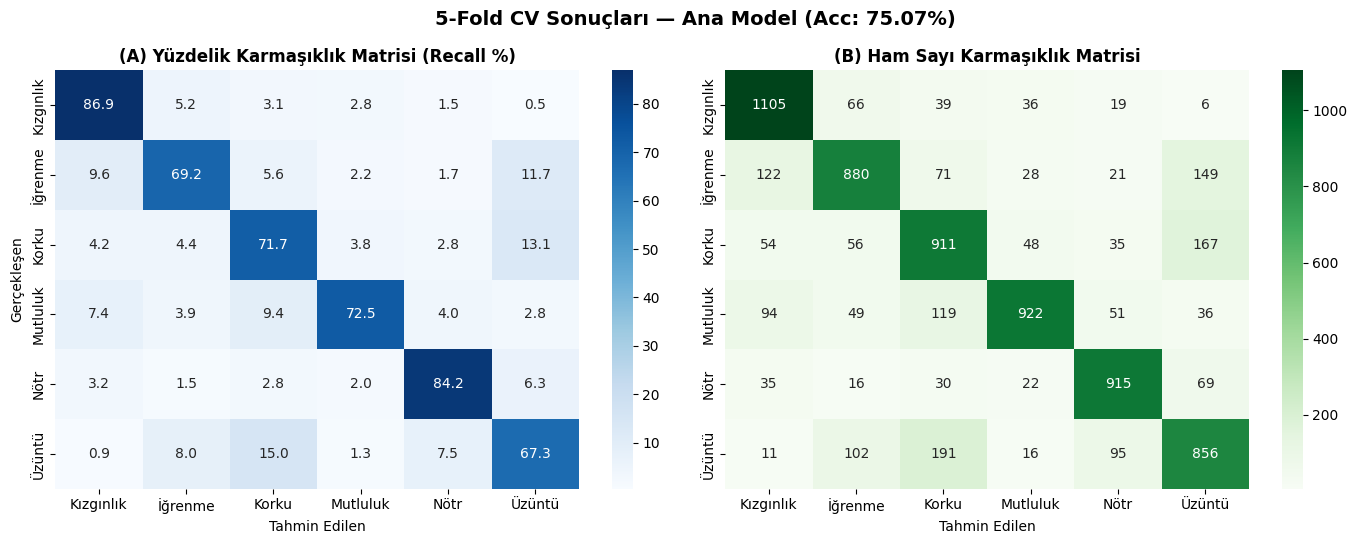

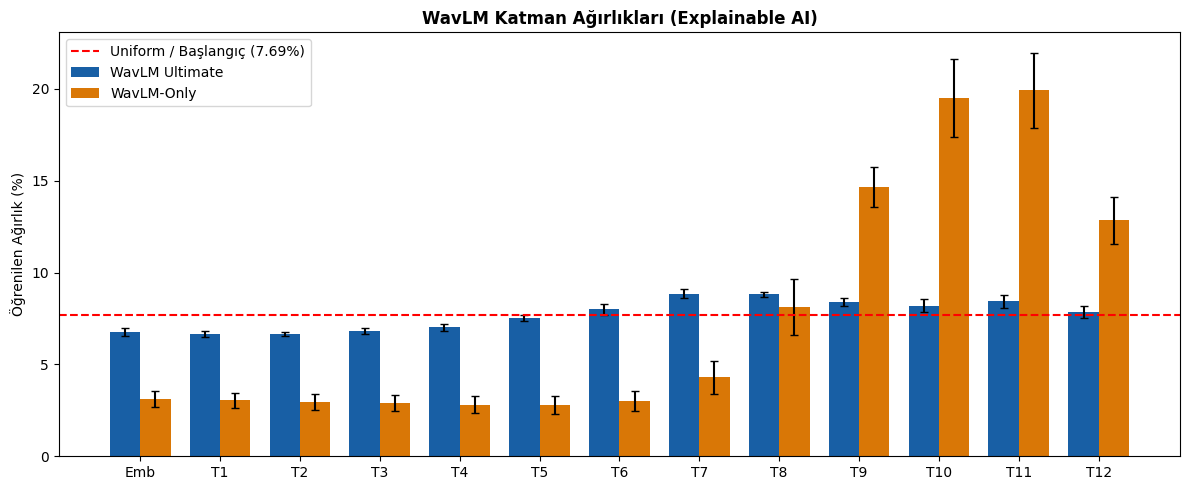

In [5]:
print("=" * 55)
print("1. AŞAMA: MFCC + SVM (BASELINE / REFERANS)")
print("=" * 55)

def extract_mfcc(path, sr=SR, n_mfcc=40):
    wav, orig_sr = torchaudio.load(path)
    if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
    if orig_sr != sr:    wav = T.Resample(orig_sr, sr)(wav)
    mfcc = T.MFCC(sample_rate=sr, n_mfcc=n_mfcc)(wav).squeeze(0)
    return torch.cat([mfcc.mean(1), mfcc.std(1)]).numpy()

print("MFCC özellikleri çıkarılıyor, lütfen bekleyin...")
features = np.stack([extract_mfcc(p) for p in df['path']])
lbl_arr  = df['label'].values

baseline_accs, baseline_f1s = [], []
for fold_id, (tr_idx, vl_idx) in enumerate(splits, 1):
    pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10, gamma='scale'))
    pipe.fit(features[tr_idx], lbl_arr[tr_idx])
    preds_b = pipe.predict(features[vl_idx])
    baseline_accs.append(accuracy_score(lbl_arr[vl_idx], preds_b) * 100)
    baseline_f1s.append(f1_score(lbl_arr[vl_idx], preds_b, average='macro') * 100)

bl_mean_acc, bl_std_acc = np.mean(baseline_accs), np.std(baseline_accs)
print(f"✓ MFCC+SVM Başarısı: {bl_mean_acc:.2f}% ± {bl_std_acc:.2f}%\n")


print("=" * 55)
print("2. AŞAMA: ANA MODEL — WavLM Ultimate (SE + Attn + MSD)")
print("=" * 55)

main_accs, main_f1s         = [], []
all_preds_cv, all_labels_cv = [], []
all_lw_tcn                  = []

for fold_id, (tr_idx, vl_idx) in enumerate(splits, 1):
    print(f"\n{'─'*20} FOLD {fold_id}/5 {'─'*20}")
    acc, f1, preds, labels, lw = run_fold(df.iloc[tr_idx], df.iloc[vl_idx], WavLM_Ultimate, fold_id)
    main_accs.append(acc)
    main_f1s.append(f1)
    all_preds_cv.extend(preds)     
    all_labels_cv.extend(labels)   
    if lw is not None: all_lw_tcn.append(lw) 
    print(f"Fold {fold_id} Sonucu -> Accuracy: {acc:.2f}%")

mean_acc = np.mean(main_accs)
std_acc  = np.std(main_accs)
mean_f1  = np.mean(main_f1s)
std_f1   = np.std(main_f1s)


print("\n" + "=" * 55)
print("3. AŞAMA: ABLASYON — WavLM-Only")
print("=" * 55)

ablation_accs, ablation_f1s = [], []
all_lw_only                 = []

for fold_id, (tr_idx, vl_idx) in enumerate(splits, 1):
    print(f"Fold {fold_id} Eğitiliyor (Ablasyon)...")
    acc, f1, _, _, lw = run_fold(df.iloc[tr_idx], df.iloc[vl_idx], WavLM_Only, fold_id + 100)
    ablation_accs.append(acc)
    ablation_f1s.append(f1)
    if lw is not None: all_lw_only.append(lw)

abl_mean = np.mean(ablation_accs)
abl_std  = np.std(ablation_accs)


print("\n" + "=" * 55)
print("MODEL KARŞILAŞTIRMA TABLOSU (İstatistiksel Analiz)")
print("=" * 55)

t_stat, p_ttest = stats.ttest_rel(main_accs, ablation_accs)
t2, p2 = stats.ttest_rel(main_accs, baseline_accs)

summary = pd.DataFrame({
    'Model'             : ['MFCC + SVM', 'WavLM-Only', 'WavLM Ultimate (Ours)'],
    'Acc (%)'           : [f"{bl_mean_acc:.2f} ± {bl_std_acc:.2f}", f"{abl_mean:.2f} ± {abl_std:.2f}", f"{mean_acc:.2f} ± {std_acc:.2f}"],
    'F1 (%)'            : [f"{np.mean(baseline_f1s):.2f} ± {np.std(baseline_f1s):.2f}", f"{np.mean(ablation_f1s):.2f} ± {np.std(ablation_f1s):.2f}", f"{mean_f1:.2f} ± {std_f1:.2f}"],
    'p vs Baseline'     : ["—", f"{p2:.4f}*" if p2 < 0.05 else f"{p2:.4f}", "ref"],
    'p vs WavLM-Only'   : ["—", "ref", f"{p_ttest:.4f}*" if p_ttest < 0.05 else f"{p_ttest:.4f}"],
})
print(summary.to_string(index=False))

# --- ÇİZİMLER ---
cm = confusion_matrix(all_labels_cv, all_preds_cv)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', xticklabels=EMOTION_TR, yticklabels=EMOTION_TR, ax=axes[0])
axes[0].set_title('(A) Yüzdelik Karmaşıklık Matrisi (Recall %)', fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen'); axes[0].set_ylabel('Gerçekleşen')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=EMOTION_TR, yticklabels=EMOTION_TR, ax=axes[1])
axes[1].set_title('(B) Ham Sayı Karmaşıklık Matrisi', fontweight='bold')
axes[1].set_xlabel('Tahmin Edilen'); axes[1].set_ylabel('')

plt.suptitle(f'5-Fold CV Sonuçları — Ana Model (Acc: {mean_acc:.2f}%)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

mean_lw_tcn  = np.mean(np.stack(all_lw_tcn), axis=0)
std_lw_tcn   = np.std(np.stack(all_lw_tcn), axis=0)
mean_lw_only = np.mean(np.stack(all_lw_only), axis=0)
std_lw_only  = np.std(np.stack(all_lw_only), axis=0)

x = np.arange(13)
width = 0.38
xlabs = ['Emb'] + [f'T{i}' for i in range(1, 13)]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
ax.bar(x - width/2, mean_lw_tcn * 100, width, yerr=std_lw_tcn * 100, capsize=3, label='WavLM Ultimate', color='#185FA5')
ax.bar(x + width/2, mean_lw_only * 100, width, yerr=std_lw_only * 100, capsize=3, label='WavLM-Only', color='#D97706')
ax.axhline(100/13, color='red', linestyle='--', label='Uniform / Başlangıç (7.69%)')

ax.set_xticks(x); ax.set_xticklabels(xlabs)
ax.set_title('WavLM Katman Ağırlıkları (Explainable AI)', fontweight='bold')
ax.set_ylabel('Öğrenilen Ağırlık (%)')
ax.legend()
plt.tight_layout()
plt.show()